In [1]:
# Importujemy biblioteki
import pandas as pd

# Wczytujemy dane
df = pd.read_excel('../data/online_retail_raw.xlsx')

# Sprawdzamy ile mamy wierszy i kolumn
print(df.shape)

(541909, 8)


In [2]:
# Podglądamy 5 pierwszych wierszy
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
# Podstawowe informacje o datasecie
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [4]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [5]:
# Sprawdzamy ile mamy zwrotów
zwroty = df[df['Quantity'] < 0]
print(f'Liczba zwrotów: {len(zwroty)}')
print(f'Procent wszystkich transakcji: {len(zwroty)/len(df)*100:.1f}%')

Liczba zwrotów: 10624
Procent wszystkich transakcji: 2.0%


In [6]:
# Czyszczenie danych
# Krok 1: Usuwamy zwroty i błędne ceny
df_clean = df[df['Quantity'] > 0]
df_clean = df_clean[df_clean['UnitPrice'] > 0]

# Krok 2: Usuwamy wiersze bez CustomerID
df_clean = df_clean.dropna(subset=['CustomerID'])

# Krok 3: Usuwamy wiersze bez nazwy produktu
df_clean = df_clean.dropna(subset=['Description'])

# Krok 4: Zmieniamy CustomerID na int
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

# Sprawdzamy efekt czyszczenia
print(f'Przed czyszczeniem: {len(df)} wierszy')
print(f'Po czyszczeniu: {len(df_clean)}')
print(f'Usunięto: {len(df) - len(df_clean)} wierszy ({(len(df) - len(df_clean))/len(df)*100:.1f}%)')

Przed czyszczeniem: 541909 wierszy
Po czyszczeniu: 397884
Usunięto: 144025 wierszy (26.6%)


In [7]:
# Tworzymy kolumnę przychodu
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Podglądamy efekt
df_clean[['InvoiceNo', 'Description', 'Quantity', 'UnitPrice', 'Revenue']].head()

,InvoiceNo,Description,Quantity,UnitPrice,Revenue
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,15.30
1,536365,WHITE METAL LANTERN,6,3.39,20.34
2,536365,CREAM CUPID HEARTS COAT HANGER,8,2.75,22.00
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,20.34
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,20.34


> Pierwsze pytanie szefa:

>>"Które produkty sprzedają się najlepiej?"

In [8]:
# Top 10 produktów według przychodu
top_produkty = df_clean.groupby('Description')['Revenue'].sum()
top_produkty = top_produkty.sort_values(ascending=False)
top_produkty = top_produkty.head(10)

print(top_produkty)

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
JUMBO BAG RED RETROSPOT                85220.78
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68844.33
ASSORTED COLOUR BIRD ORNAMENT          56580.34
Manual                                 53779.93
RABBIT NIGHT LIGHT                     51346.20
Name: Revenue, dtype: float64


In [9]:
# Usuwamy niby produkty z listy
produkty_do_usuniecia = ['POSTAGE', 'Manual', 'AMAZONFEE', 'BANK CHARGES', 'DOT']
df_clean = df_clean[~df_clean['Description'].isin(produkty_do_usuniecia)]

# Top 10 produktów po oczyszczeniu
top_produkty = df_clean.groupby('Description')['Revenue'].sum()
top_produkty = top_produkty.sort_values(ascending=False)
top_produkty = top_produkty.head(10)

print(top_produkty)

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
JUMBO BAG RED RETROSPOT                85220.78
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
PARTY BUNTING                          68844.33
ASSORTED COLOUR BIRD ORNAMENT          56580.34
RABBIT NIGHT LIGHT                     51346.20
CHILLI LIGHTS                          46286.51
PAPER CHAIN KIT 50'S CHRISTMAS         42660.83
Name: Revenue, dtype: float64


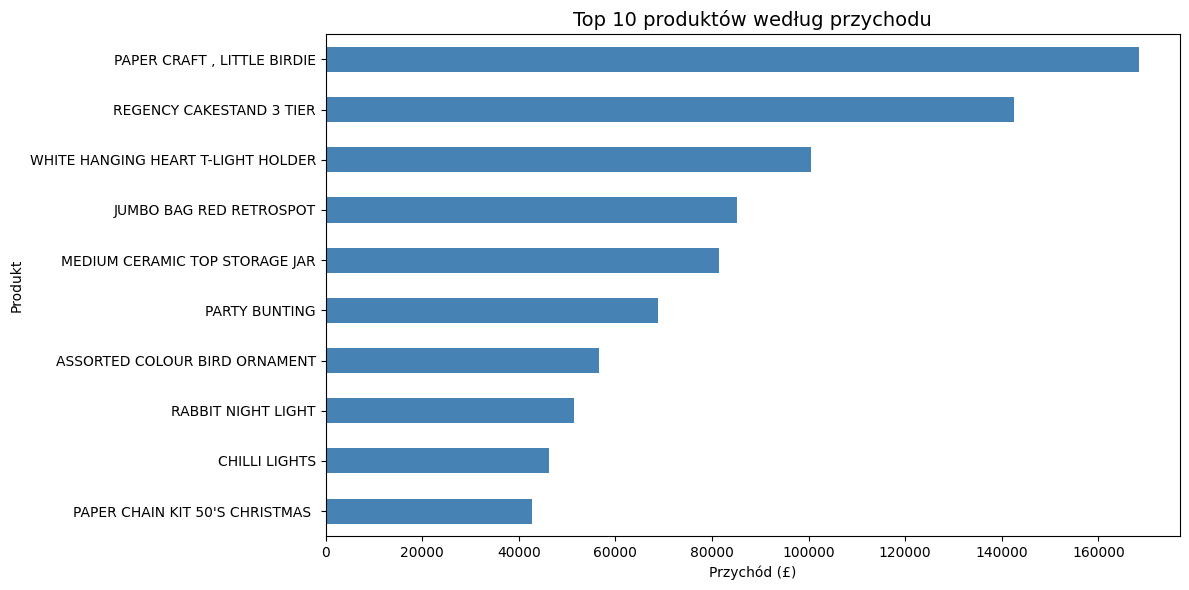

In [10]:
import matplotlib.pyplot as plt

# Wykres Top 10 produktów
plt.figure(figsize=(12, 6))
top_produkty.sort_values().plot(kind='barh', color='steelblue')

plt.title('Top 10 produktów według przychodu', fontsize=14)
plt.xlabel('Przychód (£)')
plt.ylabel('Produkt')
plt.tight_layout()
plt.savefig('../reports/top10_produkty.png', dpi=150)
plt.show()

> Drugie pytanie szefa brzmiało:

>> "Jak wyglądają nasze miesięczne przychody?"

In [15]:
# Wyciągamy miesiąc i rok z daty
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')

# Sumujemy przychód per miesiąc
miesieczne_przychody = df_clean.groupby('YearMonth')['Revenue'].sum()

print(miesieczne_przychody)

YearMonth
2010-12     568055.720
2011-01     564241.640
2011-02     443546.020
2011-03     585262.850
2011-04     455681.911
2011-05     660932.900
2011-06     654932.560
2011-07     593231.901
2011-08     637168.410
2011-09     943512.642
2011-10    1009781.660
2011-11    1148481.110
2011-12     514994.690
Freq: M, Name: Revenue, dtype: float64


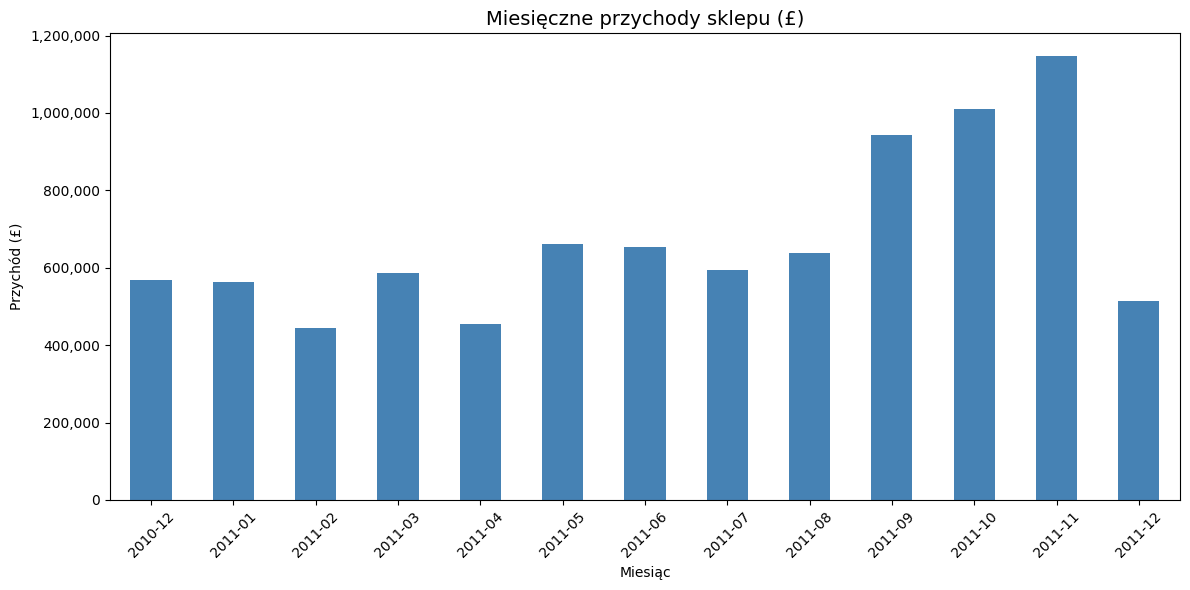

In [24]:
# Wykres miesięcznych przychodów
import matplotlib.ticker as mticker

plt.figure(figsize=(12, 6))
miesieczne_przychody.plot(kind='bar', color='steelblue')

plt.title('Miesięczne przychody sklepu (£)', fontsize=14)
plt.xlabel('Miesiąc')
plt.ylabel('Przychód (£)')
plt.xticks(rotation=45)

# Formatujemy oś Y na normalne liczby z separatorem tysięcy
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('../reports/miesieczne_przychody.png', dpi=150)
plt.show()

>Trzecie pytanie biznesowe:

>>"Z jakich krajów pochodzi najwięcej przychodów?"

In [26]:
# Top 10 krajów
top_kraje = df_clean.groupby('Country')['Revenue'].sum()
top_kraje = top_kraje.sort_values(ascending=False)
top_kraje = top_kraje.head(10)

print(top_kraje)

Country
United Kingdom    7279408.594
Netherlands        283889.340
EIRE               262171.560
Germany            205569.890
France             184077.680
Australia          138171.310
Spain               55725.110
Switzerland         52441.950
Japan               37416.370
Belgium             36927.340
Name: Revenue, dtype: float64


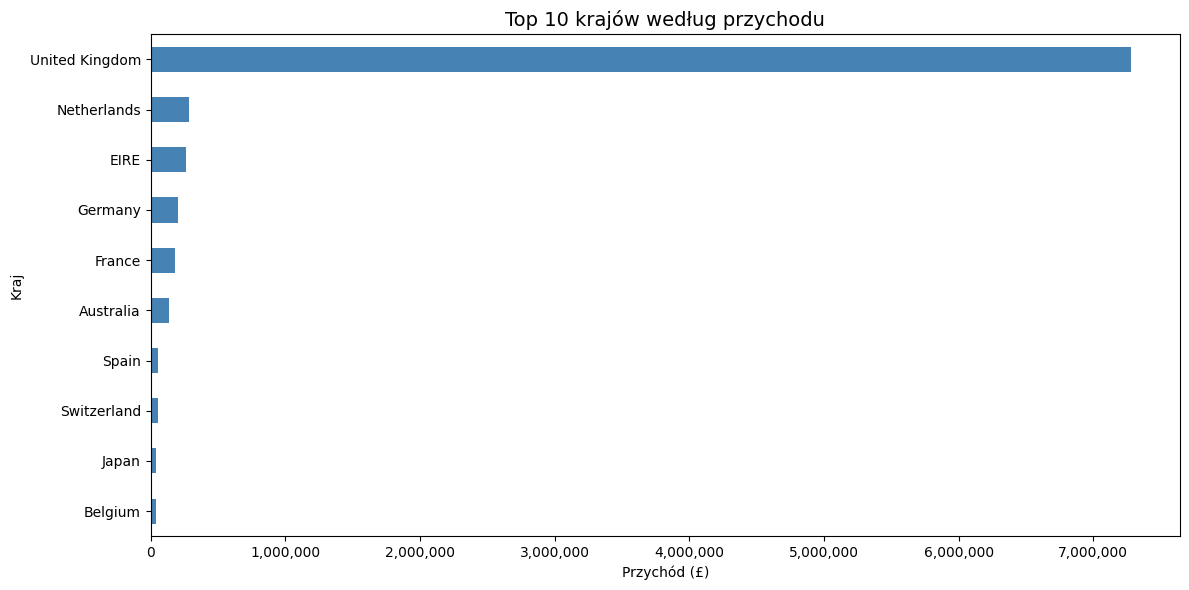

In [42]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Wykres Top 10 krajów
plt.figure(figsize=(12, 6))
top_kraje.sort_values().plot(kind='barh', color='steelblue')

plt.title('Top 10 krajów według przychodu', fontsize=14)
plt.xlabel('Przychód (£)')
plt.ylabel('Kraj')

# Formatujemy oś X na normalne liczby z separatorem tysięcy
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('../reports/top10_kraje.png', dpi=150)
plt.show()